# Global Socio-Economic Indicator Analysis Dashboard

## Problem Statement
This project aims to analyze global socio-economic indicators across different countries, regions, and income groups to identify patterns, disparities, and relationships between economic factors and indicator values.

The analysis focuses on understanding how socio-economic indicators vary across geographical regions and economic categories, and how factors like GDP per capita influence these indicators.


In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import hvplot.pandas
import panel as pn

pn.extension("tabulator")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Load Dataset

In [66]:
df = pd.read_excel("dashboard-data-april-download.xlsx", sheet_name="2. Harmonized Indicators")
df.head()

,row_id,code,country,region_code,region,wave,month,year,indicator_topic,indicator,...,unit_measure,measure_type,GDP_pc,ln_GDP_pc,weight_type,footnote,survey_producer,survey_link,last_updated,source
0,1,AFG,Afghanistan,SAR,South Asia,WAVE1,9.0,2020,Demographic,Demo_educ1,...,Percent of respondent,p,2065.036377,7.632903,Individual weight,NaN,NaN,NaN,2023-04-25,High Frequency Phone Survey
1,2,AFG,Afghanistan,SAR,South Asia,WAVE1,9.0,2020,Demographic,Demo_educ2,...,Percent of respondent,p,2065.036377,7.632903,Individual weight,(*) the category includes incomplete and compl...,NaN,NaN,2023-04-25,High Frequency Phone Survey
2,3,AFG,Afghanistan,SAR,South Asia,WAVE1,9.0,2020,Demographic,Demo_educ3,...,Percent of respondent,p,2065.036377,7.632903,Individual weight,(*) the category includes incomplete and compl...,NaN,NaN,2023-04-25,High Frequency Phone Survey
3,4,AFG,Afghanistan,SAR,South Asia,WAVE1,9.0,2020,Demographic,Demo_educ4,...,Percent of respondent,p,2065.036377,7.632903,Individual weight,(*) the category includes incomplete post-seco...,NaN,NaN,2023-04-25,High Frequency Phone Survey
4,5,AFG,Afghanistan,SAR,South Asia,WAVE1,9.0,2020,Demographic,Demo_male_sample,...,Percent of respondent,p,2065.036377,7.632903,Unweighted,NaN,NaN,NaN,2023-04-25,High Frequency Phone Survey


## Data Understanding

In [67]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (154711, 29)

Columns:
['row_id', 'code', 'country', 'region_code', 'region', 'wave', 'month', 'year', 'indicator_topic', 'indicator', 'indicator_display', 'indicator_val', 'urban_rural', 'industry', 'sample_subset', 'sample_total', 'FCS', 'income_group', 'lending_category', 'unit_measure', 'measure_type', 'GDP_pc', 'ln_GDP_pc', 'weight_type', 'footnote', 'survey_producer', 'survey_link', 'last_updated', 'source']


In [68]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 154711 entries, 0 to 154710
Data columns (total 29 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   row_id             154711 non-null  int64         
 1   code               154711 non-null  str           
 2   country            154711 non-null  str           
 3   region_code        154711 non-null  str           
 4   region             154711 non-null  str           
 5   wave               154711 non-null  str           
 6   month              154685 non-null  float64       
 7   year               154711 non-null  int64         
 8   indicator_topic    154659 non-null  str           
 9   indicator          154711 non-null  str           
 10  indicator_display  154663 non-null  str           
 11  indicator_val      154711 non-null  float64       
 12  urban_rural        147914 non-null  str           
 13  industry           154711 non-null  str           
 14 

In [69]:
df.describe(include="all")

,row_id,code,country,region_code,region,wave,month,year,indicator_topic,indicator,...,unit_measure,measure_type,GDP_pc,ln_GDP_pc,weight_type,footnote,survey_producer,survey_link,last_updated,source
count,154711.000000,154711,154711,154711,154711,154711,154685.000000,154711.000000,154659,154711,...,154659,154659,153483.000000,153483.000000,154661,7471,104912,102023,154711,154711
unique,NaN,89,90,6,6,33,NaN,NaN,16,154,...,6,2,NaN,NaN,3,12,28,58,NaN,2
top,NaN,TJK,Tajikistan,SSA,Sub-Saharan Africa,WAVE1,NaN,NaN,Demographic,Demo_hsize,...,Percent of households,p,NaN,NaN,Household weight,(*) The universe of this indicator is responde...,Sistemas Integrales. World Bank.,https://microdata.worldbank.org/index.php/cata...,NaN,High Frequency Phone Survey
freq,NaN,5346,5346,52804,52804,48800,NaN,NaN,26179,4229,...,87747,149072,NaN,NaN,148199,6614,35241,5769,NaN,154699
mean,77356.002139,NaN,NaN,NaN,NaN,NaN,6.908272,2020.504554,NaN,NaN,...,NaN,NaN,8983.491072,8.733711,NaN,NaN,NaN,NaN,2023-04-25 00:00:00,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,1.000000,2020.000000,NaN,NaN,...,NaN,NaN,861.766785,6.758985,NaN,NaN,NaN,NaN,2023-04-25 00:00:00,NaN
25%,38678.500000,NaN,NaN,NaN,NaN,NaN,5.000000,2020.000000,NaN,NaN,...,NaN,NaN,2616.863037,7.869731,NaN,NaN,NaN,NaN,2023-04-25 00:00:00,NaN
50%,77356.000000,NaN,NaN,NaN,NaN,NaN,6.000000,2020.000000,NaN,NaN,...,NaN,NaN,7348.146973,8.902204,NaN,NaN,NaN,NaN,2023-04-25 00:00:00,NaN
75%,116033.500000,NaN,NaN,NaN,NaN,NaN,9.000000,2021.000000,NaN,NaN,...,NaN,NaN,12735.167969,9.452123,NaN,NaN,NaN,NaN,2023-04-25 00:00:00,NaN
max,154712.000000,NaN,NaN,NaN,NaN,NaN,12.000000,2022.000000,NaN,NaN,...,NaN,NaN,33159.750000,10.409092,NaN,NaN,NaN,NaN,2023-04-25 00:00:00,NaN


## Data Cleaning and Preprocessing

In [70]:
# Drop irrelevant / highly missing columns
df = df.drop(columns=[
    'footnote',
    'FCS',
    'survey_producer',
    'survey_link',
    'row_id',
    'code',
    'region_code'
])

In [71]:
df.isnull().sum()

country                 0
region                  0
wave                    0
month                  26
year                    0
indicator_topic        52
indicator               0
indicator_display      48
indicator_val           0
urban_rural          6797
industry                0
sample_subset           0
sample_total            0
income_group           52
lending_category        0
unit_measure           52
measure_type           52
GDP_pc               1228
ln_GDP_pc            1228
weight_type            50
last_updated            0
source                  0
dtype: int64

In [72]:
# Fill missing values
df['month'] = df['month'].fillna(df['month'].median())
df['urban_rural'] = df['urban_rural'].fillna(df['urban_rural'].mode()[0])
df['GDP_pc'] = df['GDP_pc'].fillna(df['GDP_pc'].median())
df['ln_GDP_pc'] = df['ln_GDP_pc'].fillna(df['ln_GDP_pc'].median())

df['indicator_topic'] = df['indicator_topic'].fillna("Unknown")
df['indicator_display'] = df['indicator_display'].fillna("Unknown")
df['income_group'] = df['income_group'].fillna("Unknown")
df['unit_measure'] = df['unit_measure'].fillna("Unknown")
df['measure_type'] = df['measure_type'].fillna("Unknown")
df['weight_type'] = df['weight_type'].fillna("Unknown")

# Check remaining missing values
df.isnull().sum()

country              0
region               0
wave                 0
month                0
year                 0
indicator_topic      0
indicator            0
indicator_display    0
indicator_val        0
urban_rural          0
industry             0
sample_subset        0
sample_total         0
income_group         0
lending_category     0
unit_measure         0
measure_type         0
GDP_pc               0
ln_GDP_pc            0
weight_type          0
last_updated         0
source               0
dtype: int64

In [73]:
print("Updated Shape:", df.shape)
df.head()
# Data cleaning completed

Updated Shape: (154711, 22)


,country,region,wave,month,year,indicator_topic,indicator,indicator_display,indicator_val,urban_rural,...,sample_total,income_group,lending_category,unit_measure,measure_type,GDP_pc,ln_GDP_pc,weight_type,last_updated,source
0,Afghanistan,South Asia,WAVE1,9.0,2020,Demographic,Demo_educ1,Level of education - No education,70.007744,National,...,5057.0,Low income,IDA,Percent of respondent,p,2065.036377,7.632903,Individual weight,2023-04-25,High Frequency Phone Survey
1,Afghanistan,South Asia,WAVE1,9.0,2020,Demographic,Demo_educ2,Level of education - Any Primary,4.748603,National,...,5057.0,Low income,IDA,Percent of respondent,p,2065.036377,7.632903,Individual weight,2023-04-25,High Frequency Phone Survey
2,Afghanistan,South Asia,WAVE1,9.0,2020,Demographic,Demo_educ3,Level of education - Any Secondary,15.522991,National,...,5057.0,Low income,IDA,Percent of respondent,p,2065.036377,7.632903,Individual weight,2023-04-25,High Frequency Phone Survey
3,Afghanistan,South Asia,WAVE1,9.0,2020,Demographic,Demo_educ4,Level of education - Any Post Secondary,9.720658,National,...,5057.0,Low income,IDA,Percent of respondent,p,2065.036377,7.632903,Individual weight,2023-04-25,High Frequency Phone Survey
4,Afghanistan,South Asia,WAVE1,9.0,2020,Demographic,Demo_male_sample,Male respondents (% of respondents unweighted),70.512566,National,...,5057.0,Low income,IDA,Percent of respondent,p,2065.036377,7.632903,Unweighted,2023-04-25,High Frequency Phone Survey


## Feature Engineering

In [74]:
# Create GDP category
df['GDP_Category'] = pd.qcut(
    df['GDP_pc'],
    q=4,
    labels=['Low GDP', 'Lower-Mid GDP', 'Upper-Mid GDP', 'High GDP']
)

# Create indicator value category
df['Value_Category'] = pd.qcut(
    df['indicator_val'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Very High']
)

# Select important indicators for focused analysis
selected_indicators = [
    "Average household size",
    "Male respondents (% of respondents weighted by household weight)",
    "Employed respondents who are wage employee (% of working respondents above 18 years old)",
    "Employed respondents who are self-employed (% of working respondents above 18 years old)",
    "In the last 30 days, went without eating for a whole day due to lack of money (% of HHs)",
    "In the last 30 days, you ran out of food due to a lack of money or other resources? (% of HHs)",
    "Level of education - No education",
    "Level of education - Any Primary"
]

df_filtered = df[df['indicator_display'].isin(selected_indicators)].copy()

In [75]:
print("Filtered Shape:", df_filtered.shape)
print("Number of selected indicators:", df_filtered['indicator_display'].nunique())

df_filtered[['GDP_pc', 'GDP_Category', 'indicator_val', 'Value_Category']].head()

Filtered Shape: (25905, 24)
Number of selected indicators: 8


,GDP_pc,GDP_Category,indicator_val,Value_Category
0,2065.036377,Low GDP,70.007744,High
1,2065.036377,Low GDP,4.748603,Low
17,2065.036377,Low GDP,58.497284,High
18,2065.036377,Low GDP,72.625961,Very High
19,2065.036377,Low GDP,65.450279,High


In [76]:
df_filtered['indicator_display'].value_counts()

indicator_display
Average household size                                                                            4229
Male respondents (% of respondents weighted by household weight)                                  4077
Employed respondents who are wage employee (% of working respondents above 18 years old)          3081
Employed respondents who are self-employed (% of working respondents above 18 years old)          3022
In the last 30 days, went without eating for a whole day due to lack of money (% of HHs)          2991
In the last 30 days, you ran out of food due to a lack of money or other resources? (% of HHs)    2955
Level of education - No education                                                                 2775
Level of education - Any Primary                                                                  2775
Name: count, dtype: int64

## Exploratory Data Analysis

In [77]:
print("Shape:", df_filtered.shape)

print("\nUnique Countries:", df_filtered['country'].nunique())
print("Unique Regions:", df_filtered['region'].nunique())
print("Unique Years:", df_filtered['year'].nunique())
print("Unique Indicators:", df_filtered['indicator_display'].nunique())

Shape: (25905, 24)

Unique Countries: 89
Unique Regions: 6
Unique Years: 3
Unique Indicators: 8


In [78]:
df_filtered.isnull().sum()

country              0
region               0
wave                 0
month                0
year                 0
indicator_topic      0
indicator            0
indicator_display    0
indicator_val        0
urban_rural          0
industry             0
sample_subset        0
sample_total         0
income_group         0
lending_category     0
unit_measure         0
measure_type         0
GDP_pc               0
ln_GDP_pc            0
weight_type          0
last_updated         0
source               0
GDP_Category         0
Value_Category       0
dtype: int64

In [79]:
df_filtered[['indicator_val', 'GDP_pc', 'ln_GDP_pc', 'sample_total']].describe()

,indicator_val,GDP_pc,ln_GDP_pc,sample_total
count,25905.000000,25905.000000,25905.000000,25905.000000
mean,27.385609,9721.165506,8.829195,1795.301718
std,25.484309,7650.401751,0.894284,2556.156389
min,0.000000,861.766785,6.758985,288.000000
25%,4.945681,3575.279785,8.181799,951.000000
50%,18.991472,8528.749023,9.051198,1396.000000
75%,46.060242,13609.722656,9.518539,2000.000000
max,100.000000,33159.750000,10.409092,46053.000000


In [80]:
df_filtered[['indicator_val', 'GDP_pc', 'ln_GDP_pc', 'sample_total']].skew()

df_filtered[['indicator_val', 'GDP_pc', 'ln_GDP_pc', 'sample_total']].kurt()

indicator_val     -0.398110
GDP_pc             0.189907
ln_GDP_pc         -1.019099
sample_total     240.331938
dtype: float64

In [81]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

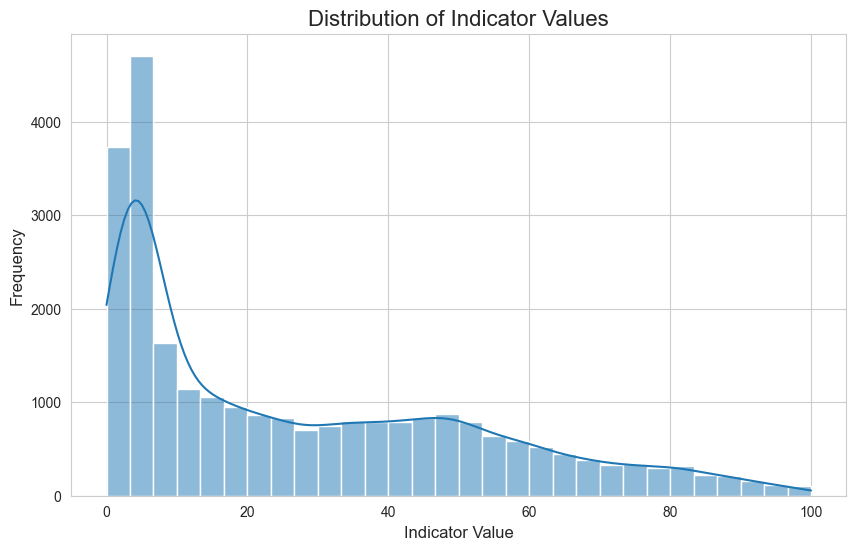

In [82]:
sns.histplot(df_filtered['indicator_val'], bins=30, kde=True)
plt.title("Distribution of Indicator Values")
plt.xlabel("Indicator Value")
plt.ylabel("Frequency")
plt.show()

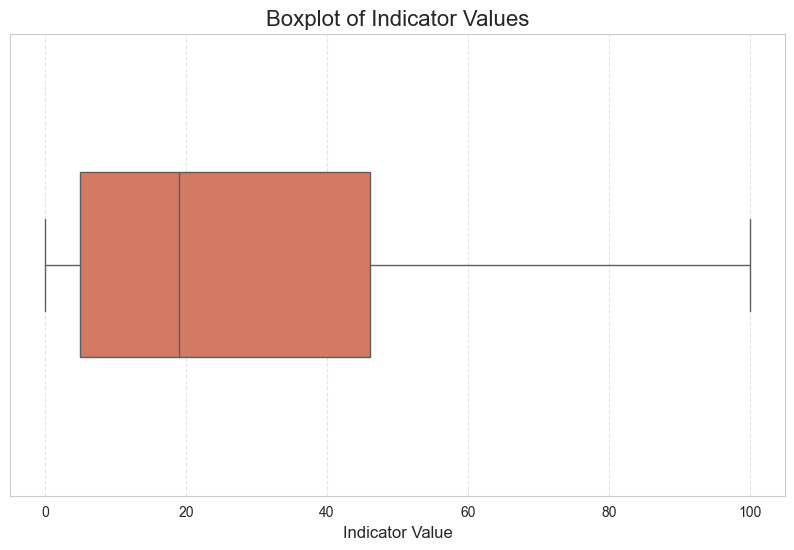

In [83]:
sns.boxplot(
    x=df_filtered['indicator_val'],
    color="#e76f51",
    width=0.4
)
plt.title("Boxplot of Indicator Values")
plt.xlabel("Indicator Value")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

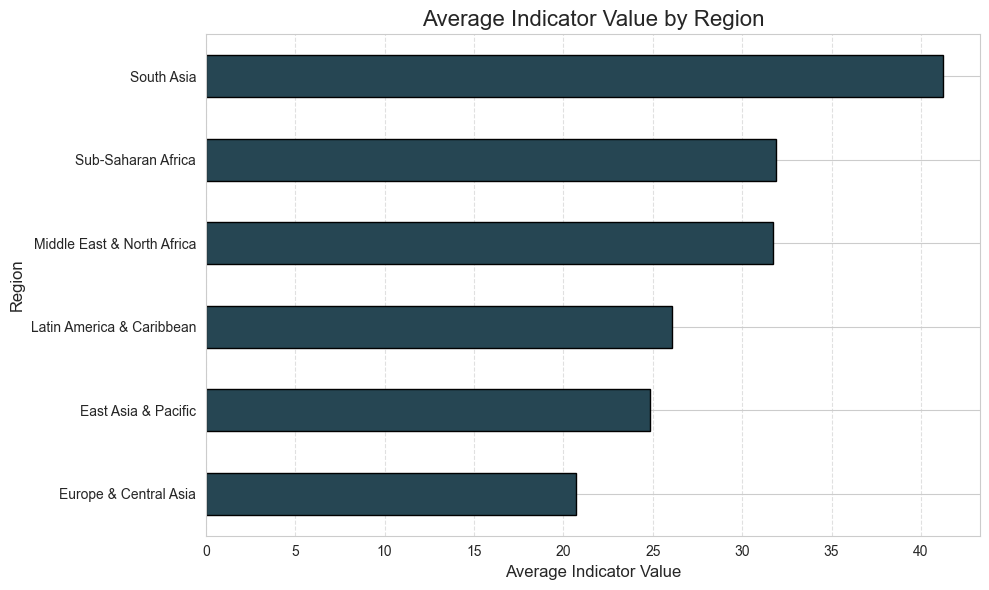

In [84]:
region_avg = df_filtered.groupby('region')['indicator_val'].mean().sort_values()
region_avg.plot(
    kind='barh',
    color="#264653",
    edgecolor="black"
)
plt.title("Average Indicator Value by Region")
plt.xlabel("Average Indicator Value")
plt.ylabel("Region")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

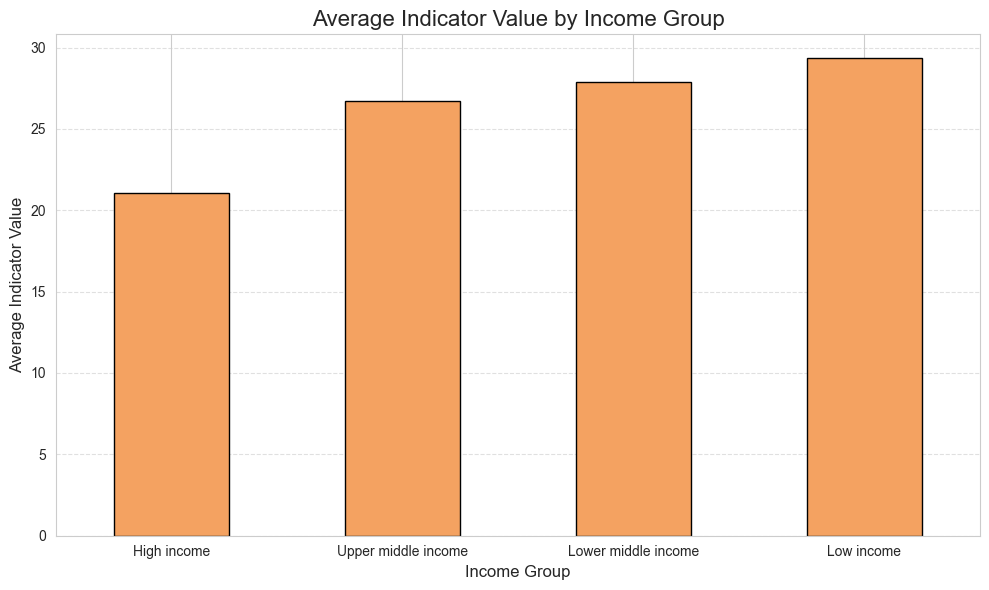

In [85]:
income_avg = df_filtered.groupby('income_group')['indicator_val'].mean().sort_values()
income_avg.plot(
    kind='bar',
    color="#f4a261",
    edgecolor="black"
)
plt.title("Average Indicator Value by Income Group")
plt.ylabel("Average Indicator Value")
plt.xlabel("Income Group")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Statistical Analysis

In [86]:
df_filtered[['indicator_val', 'GDP_pc', 'ln_GDP_pc', 'sample_total']].describe()

,indicator_val,GDP_pc,ln_GDP_pc,sample_total
count,25905.000000,25905.000000,25905.000000,25905.000000
mean,27.385609,9721.165506,8.829195,1795.301718
std,25.484309,7650.401751,0.894284,2556.156389
min,0.000000,861.766785,6.758985,288.000000
25%,4.945681,3575.279785,8.181799,951.000000
50%,18.991472,8528.749023,9.051198,1396.000000
75%,46.060242,13609.722656,9.518539,2000.000000
max,100.000000,33159.750000,10.409092,46053.000000


In [87]:
corr_matrix = df_filtered[['indicator_val', 'GDP_pc', 'ln_GDP_pc', 'sample_total']].corr()
corr_matrix

,indicator_val,GDP_pc,ln_GDP_pc,sample_total
indicator_val,1.000000,-0.097724,-0.099960,0.052980
GDP_pc,-0.097724,1.000000,0.921052,-0.140644
ln_GDP_pc,-0.099960,0.921052,1.000000,-0.131038
sample_total,0.052980,-0.140644,-0.131038,1.000000


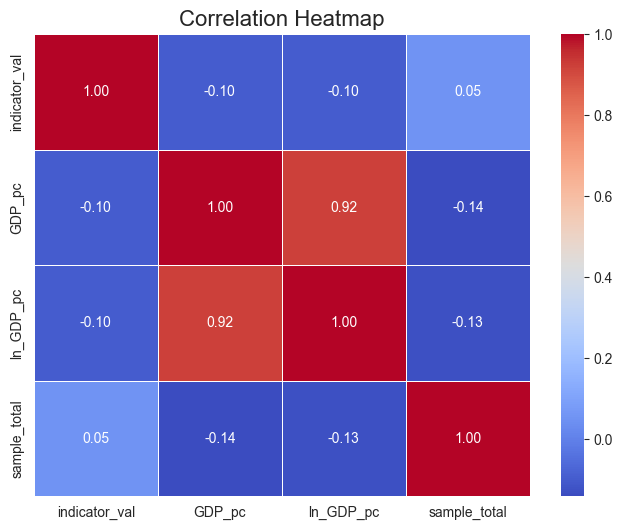

In [88]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

In [89]:
print("Skewness:\n", df_filtered[['indicator_val', 'GDP_pc', 'ln_GDP_pc']].skew())
print("\nKurtosis:\n", df_filtered[['indicator_val', 'GDP_pc', 'ln_GDP_pc']].kurt())

Skewness:
 indicator_val    0.816805
GDP_pc           0.984558
ln_GDP_pc       -0.234358
dtype: float64

Kurtosis:
 indicator_val   -0.398110
GDP_pc           0.189907
ln_GDP_pc       -1.019099
dtype: float64


In [90]:
df_filtered.groupby('region')['indicator_val'].agg(['mean', 'median', 'std'])

,mean,median,std
region,,,
East Asia & Pacific,24.837933,14.237333,25.042344
Europe & Central Asia,20.703170,6.890726,23.478006
Latin America & Caribbean,26.085606,20.304571,23.127929
Middle East & North Africa,31.738526,19.448654,29.554661
South Asia,41.240106,35.754921,24.286052
Sub-Saharan Africa,31.889929,23.298457,27.532091


In [91]:
df_filtered.groupby('income_group')['indicator_val'].agg(['mean', 'median', 'std'])

,mean,median,std
income_group,,,
High income,21.066020,9.318584,23.701582
Low income,29.338812,18.305933,26.946000
Lower middle income,27.883306,20.441601,25.410003
Upper middle income,26.694723,19.786665,24.579836


## Final Visualizations

## Dashboard Filter

In [92]:
year_select = pn.widgets.RadioButtonGroup(
    name='Year',
    options=sorted(df_filtered['year'].dropna().unique().tolist()),
    value=sorted(df_filtered['year'].dropna().unique().tolist())[0],
    button_type='success'
)

In [93]:
filtered_data = pn.bind(
    lambda year: df_filtered[df_filtered['year'] == year],
    year_select
)

In [104]:
top_countries_plot = pn.bind(
    lambda data: (
        data.groupby('country')['indicator_val']
        .mean()
        .sort_values(ascending=False)
        .head(10)
        .hvplot.bar(
            title="Top 10 Countries by Indicator Value",
            color="#f77f00",
            width=700,
            height=350,
            grid=True
        )
        .opts(
            xrotation=45   
        )
    ) if not data.empty else pn.pane.Markdown("No data available."),
    filtered_data
)

In [95]:
distribution_plot = pn.bind(
    lambda data: (
        data[data['indicator_val'] <= data['indicator_val'].quantile(0.95)]
        .hvplot.hist(
            y='indicator_val',
            bins=15,
            title='Distribution of Indicator Values',
            color='#7fb069',
            alpha=0.85,
            width=450,
            height=320,
            grid=True
        )
        .opts(
            xlabel='Indicator Value',
            ylabel='Frequency',
            toolbar='above'
        )
    ) if not data.empty else pn.pane.Markdown("No data available."),
    filtered_data
)

In [100]:
gdp_scatter = pn.bind(
    lambda data: (
        data[['country', 'income_group', 'ln_GDP_pc', 'indicator_val']]
        .dropna()
        .groupby(['country', 'income_group'], as_index=False)
        .mean()
        .hvplot.scatter(
            x='ln_GDP_pc',
            y='indicator_val',
            by='income_group', 
            title='GDP vs Indicator (by Income Group)',
            size=70,
            alpha=0.75,
            height=320,
            width=650,

            grid=True,
            legend='right',      
            hover_cols=['country']
        )
        .opts(
            xlabel='Log GDP per Capita',
            ylabel='Indicator Value',
            toolbar='above'
        )
    ) if not data.empty else pn.pane.Markdown("No data available."),
    filtered_data
)

In [105]:
all_regions = sorted(df_filtered['region'].dropna().unique().tolist())

region_pie = pn.bind(
    lambda data: (
        pn.pane.Markdown("No data available.")
        if data.empty else
        (
            lambda fig_ax: (
                fig_ax[1].pie(
                    data.groupby('region')['indicator_val']
                    .mean()
                    .reindex(all_regions, fill_value=0)
                    .values,
                    labels=data.groupby('region')['indicator_val']
                    .mean()
                    .reindex(all_regions, fill_value=0)
                    .index,
                    autopct=lambda p: f'{p:.1f}%' if p > 0 else '',
                    startangle=90,
                    colors=['#264653', '#2a9d8f', '#e9c46a', '#f4a261', '#e76f51', '#8ecae6'],
                    wedgeprops={'edgecolor': 'none'}
                ),
                fig_ax[1].set_title('Regional Distribution', fontsize=15),
                fig_ax[0].subplots_adjust(left=0, right=1, top=0.9, bottom=0),
                plt.close(fig_ax[0]),
                pn.pane.Matplotlib(fig_ax[0], width=450, height=330, tight=True)
            )[-1]
        )(plt.subplots(figsize=(6, 6)))
    ),
    filtered_data
)

In [106]:
dashboard = pn.Row(
    # LEFT SIDEBAR
    pn.Column(
        pn.pane.Markdown("""
# Socio-Economic Indicators Dashboard

### Insights
- Top countries chart highlights leading countries.
- Distribution plot shows spread of indicator values.
- Scatter plot shows GDP vs indicator relationship by income group.
- Pie chart shows regional distribution.

### Filter
Select a year to update all visuals.
        """),
        
        pn.Spacer(height=20),   # spacing
        
        year_select,
        
        width=260
    ),

    # RIGHT PANEL
    pn.Column(
        # Top row
        pn.Row(
            top_countries_plot,
            pn.Spacer(width=20),
            distribution_plot
        ),
        
        pn.Spacer(height=20),

        # Bottom row (scatter + pie)
        pn.Row(
            gdp_scatter,
            pn.Spacer(width=30),
            region_pie
        ),

        width=1100
    )
)

In [107]:
pn.serve(dashboard, show=True)

Launching server at http://localhost:49821
